[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/RegimeDetector/HMM_Macro_Regime_Analysis.ipynb)

# **Corrélation indices actions-obligations : Description des régimes de marchés entre le S&P et le T-Bond 10y de 70 à 2025**

Ce code est de la description pure (full in-sample). Il initialise un HMM et le fit sur les log returns du S&P et du T-Bond 10y de 1970 à 2025 et identifie 4 régimes de marchés distincts. Pour comprendre ce que représente un régime, on utilise un objet de type RegimeStatisticalAnalyzer pour afficher les moyennes, volatilités et corrélations entre actifs conditionnellement à ce régime. Par ailleurs, des tests statistiques entre régimes sont appliqués (Levene pour les volatilités et Fisher-transfo pour les corrélations).


TO DO: rajouter le Box'M pour la matrice de cov complète





# Connection au github

In [21]:
import os
import sys
import shutil

if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 1. Suppression du repo existant
    if os.path.exists(f'/content/{repo_name}'):
        shutil.rmtree(f'/content/{repo_name}')
        print(f"🗑️ Ancien repo supprimé")

    # 2. Purge du cache Python
    for mod in list(sys.modules.keys()):
        if 'RegimeDetector' in mod:
            del sys.modules[mod]

    # 3. Clone propre
    os.chdir('/content')
    !git clone {repo_url}

    # 4. Déplacement + ajout au path
    os.chdir(f'/content/{repo_name}')
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

    print(f"✅ Répertoire actuel : {os.getcwd()}")

🗑️ Ancien repo supprimé
Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 563, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 563 (delta 122), reused 45 (delta 45), pack-reused 396 (from 3)
Receiving objects: 100% (563/563), 18.29 MiB | 33.80 MiB/s, done.
Resolving deltas: 100% (246/246), done.
✅ Répertoire actuel : /content/CorrelationEquityBond


# Installation de la librairie ssm via le repo git

In [6]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-59qlhvcp
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-59qlhvcp
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done
  Created wheel for ssm: filename=ssm-0.0.1-cp312-cp312-linux_x86_64.whl size=614353 sha256=e07ed2c4c9d7334b9fb0789d34c016ec7acb8fb51023e066067909cd1deeb144
  Stored in directory: /tmp/pip-ephem-wheel-cache-a4ngo0pz/wheels/a8/a9/68/b62b9b4d4ee3afda66bd9eec0cb2fbc9a79a7504e9d6d17397
Successfully built ssm


# Préparation des données

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv("monthly_data/dataset_with_macros.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.drop(columns="Unnamed: 0", inplace=True)

In [25]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

ASSET_VARS = ["SP500", "T10_yield", "AAA", "BAA"]
asset_names = ["S&P500", "T-bond 10y", "Aaa", "Baa"]
annualise_factor = np.sqrt(12)

MACRO_SELECTED = [
    "INDPRO", "PPIACO", "TCU", "UNRATE",
    "UMCSENT", "TB3MS", "AWHMAN"
]

# Variables plus informatives en variation trimestrielle (cycliques, réactives)
MACRO_DIFF = ["INDPRO", "PPIACO", "AWHMAN", "TCU", "UNRATE"]
# Variables plus informatives en niveau (lentes, structurelles)
MACRO_LEVEL = ["UMCSENT", "TB3MS"]

available_selected = [c for c in MACRO_SELECTED if c in df.columns]

all_cols = ASSET_VARS + available_selected
df_model = df[all_cols].dropna().copy()

# Variation trimestrielle ciblée sur les variables cycliques
df_model_aligned = df_model.copy()
for col in MACRO_DIFF:
    if col in df_model_aligned.columns:
        df_model_aligned[col] = df_model_aligned[col].pct_change(2)

df_model_aligned = df_model_aligned.dropna()

dates = df_model_aligned.index
split_date = pd.Timestamp("2025-01-01")
train_mask = (dates <= split_date) & (dates >= pd.Timestamp("1970-01-01"))
dates_train = dates[train_mask]

Y_train_raw = df_model_aligned[ASSET_VARS].values[train_mask].astype(float)
X_train_raw = df_model_aligned[available_selected].values[train_mask].astype(float)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
data_to_fit = [X_train_scaled]

T, D_macro = X_train_scaled.shape
SEED = 120
np.random.seed(SEED)

print(f"Train : {dates_train[0].date()} → {dates_train[-1].date()} ({T} mois)")
print(f"Y_train_raw shape    : {Y_train_raw.shape}")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"Variables en variation trimestrielle : {MACRO_DIFF}")
print(f"Variables en niveau                  : {MACRO_LEVEL}")

Train : 1970-02-01 → 2025-01-01 (597 mois)
Y_train_raw shape    : (597, 4)
X_train_scaled shape : (597, 7)
Variables en variation trimestrielle : ['INDPRO', 'PPIACO', 'AWHMAN', 'TCU', 'UNRATE']
Variables en niveau                  : ['UMCSENT', 'TB3MS']


# Initialisation et fit du HMM descriptif

In [26]:
from RegimeDetector.HMM_detector import HMMDetector
from RegimeDetector.RegimeStatisticalAnalyzer import RegimeStatisticalAnalyzer

detector = HMMDetector(
    n_states=4,
    random_state=42,
    kappa=0.0,
    n_restarts=10,
    n_iter=100
)

detector.fit(Y=data_to_fit)
states = detector.viterbi_states

# Analyse statistique des régimes sur les données FINANCIÈRES
analyzer = RegimeStatisticalAnalyzer(
    Y=Y_train_raw,   # ← financier, pas macro
    states=states,
    asset_names=asset_names
)

results = analyzer.full_report(
    n_boot=5000,
    alpha=0.05,
    annualise=annualise_factor,
    correction="bonferroni",
    seed=42
)

STATISTIQUES DESCRIPTIVES PAR RÉGIME

--- Régime 0  (n = 198) ---
                     S&P500:  moy = +645.6873   vol = 466.5508  (ann. 1616.1795)
                 T-bond 10y:  moy = +7.6263   vol = 2.2108  (ann. 7.6583)
                        Aaa:  moy = +8.5876   vol = 2.0198  (ann. 6.9967)
                        Baa:  moy = +9.5526   vol = 2.2500  (ann. 7.7942)
  Matrice de corrélation:
[[ 1.     -0.8128 -0.8064 -0.8031]
 [-0.8128  1.      0.9893  0.9832]
 [-0.8064  0.9893  1.      0.9953]
 [-0.8031  0.9832  0.9953  1.    ]]

--- Régime 1  (n = 274) ---
                     S&P500:  moy = +2075.1064   vol = 1375.7782  (ann. 4765.8355)
                 T-bond 10y:  moy = +3.4423   vol = 1.4841  (ann. 5.1411)
                        Aaa:  moy = +4.8986   vol = 1.4232  (ann. 4.9300)
                        Baa:  moy = +5.8443   vol = 1.4439  (ann. 5.0017)
  Matrice de corrélation:
[[ 1.     -0.3915 -0.5532 -0.5845]
 [-0.3915  1.      0.9632  0.9335]
 [-0.5532  0.9632  1.      0.987 ]

On semble donc identifier 4 régimes de marchés disincts

1.   Flight-to-quality (correl négative, haute vol, typique de 2008 ou 2020)
2.   Normal (correl positive, vol basse)
3.   Stress inflationniste (correl positive, haute vol, typique des années 70 ou de 2022)
4.   Diversification idéale (correl négative, vol basse vol, pré-2010)



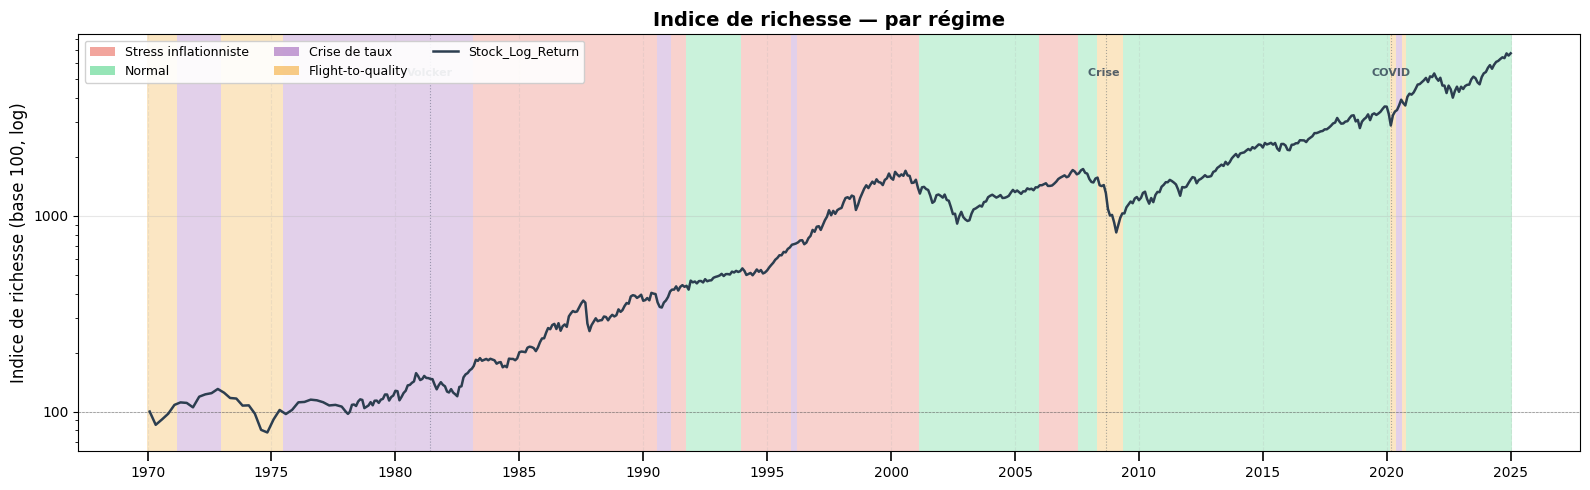

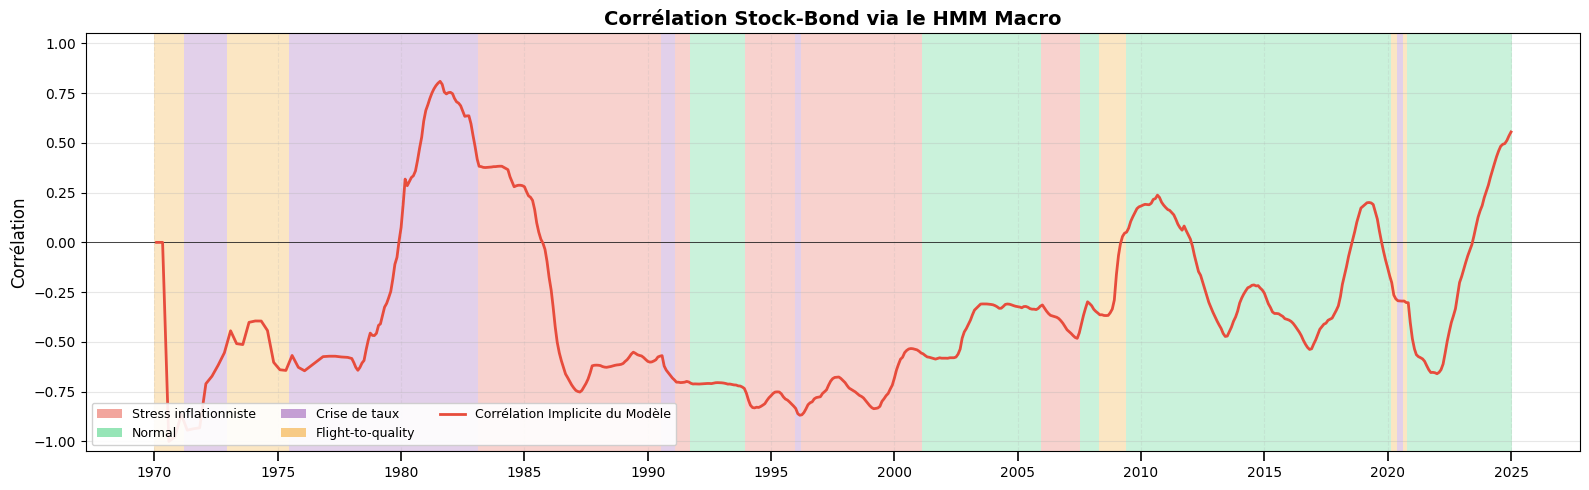

Colonnes : ['SP500', 'T10_yield', 'AAA', 'BAA']
Y[:, 0] — 5 premières valeurs : [89.5  76.55 81.52 87.2  96.75]
Moyenne : 1254.8579899497488
Ecart-type : 1280.101282569401
Min / Max : 69.97 6040.53


In [31]:
from RegimeDetector.RegimeVisualizer_EWMA import RegimeVisualizer

mes_labels = {
    0: "Stress inflationniste",   # Taux élevés, années 70-80, corr -0.81
    1: "Normal",                  # Grande Modération, corr -0.39 ✅
    2: "Crise de taux",           # Volcker shock, stress extrême, corr -0.57
    3: "Flight-to-quality"        # Corr -0.89, 2008/COVID, rare
}

mes_couleurs = {
    0: "#e74c3c",   # Rouge     → Stress inflationniste
    1: "#2ecc71",   # Vert      → Normal
    2: "#8e44ad",   # Violet    → Crise de taux (danger extrême)
    3: "#f39c12",   # Orange    → Flight-to-quality (sécurité, obligations)
}

mes_crises = {"Volcker": "1981-06-01", "Crise ": "2008-09-01","COVID": "2020-03-01",} # quelques dates pour les identifier + facilement

# Instanciation générique
visualizer = RegimeVisualizer(
    detector=detector,
    Y=Y_train_raw,
    dates=dates_train,
    states=states,
    asset_names=["Stock_Log_Return", "Bond_Log_Return"],
    regime_labels=mes_labels,
    regime_colors=mes_couleurs,
    events_dict=mes_crises
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation()

print("Colonnes :", ASSET_VARS)
print("Y[:, 0] — 5 premières valeurs :", Y_train_raw[:5, 0])
print("Moyenne :", Y_train_raw[:, 0].mean())
print("Ecart-type :", Y_train_raw[:, 0].std())
print("Min / Max :", Y_train_raw[:, 0].min(), Y_train_raw[:, 0].max())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')